# Embedding with ESM-2

In [12]:
import torch
from transformers import AutoModel, AutoTokenizer
import numpy as np
import pandas as pd
import os
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [13]:
pwd = os.getcwd()
sequence_data_file = pwd + '/data/sequence_data/BF520_protein_sequences.csv'

data_dir = pwd + '/data/raw_data/'
test_file = data_dir + 'BF520_mutDNA-1_codoncounts.csv'
reference_sequence_file = data_dir + "BF520_Reference_sequence.txt"

In [14]:
df = pd.read_csv(sequence_data_file)
print(df.head())
sequences = df['ProteinSequence'].tolist()
print(sequences[:5])

   StartNumber  EndNumber                                    ProteinSequence
0          110         94  TGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...
1            1          0  PGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...
2           70         64  VGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...
3            2          0  SGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...
4            2          4  AKNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVP...
['TGNLWVTVYYGVPVWKDAETTLFCASDAKAYDAEVHNIWATHACVPTDPNPQEINLENVTEEFNMWKNNMVEQMHTDIISLWDQGLKPCVKLTPLCVTLDCHNVTYNITSDMKEEITNCSYNVTTVIRDKKQKVSSLFYKLDVVQIGGNNRTNSQYRLINCNTSAITQACPKVTFEPIPIHYCAPAGFAILKCKDEKFNGTGLCKNVSTVQCTHGIKPVVSTQLLLNGSLAEGEVRIRSENITNNAKNIIVQLASPVTINCIRPNNNTRKSVHLGPGQAFYATDGIIGEIRQAHCNVSKKEWNSTLQKVANQLRPYFKNNTIIKFANSSGGDLEITTHSFNCGGEFFYCNTSGLFNSTWEFNSTWNNSNSTENITLQCRIKQIINMWQRAGQAIYAPPIPGVIRCKSNITGLILTRDGGSNKNTSETFRPGGGDMRDNWRSELYKYKVVKIEPIGVAPTRAKRRVVEREKRAVGIGAVFIGFLGAAGSTMGAASVTLTVQARQLLSGIVQQQSNLLRAIEAQQHLLKLTVWGIKQL

In [15]:
print(len(sequences))
start_num_sum = df['StartNumber'].sum()
end_num_sum = df['EndNumber'].sum()
print(start_num_sum, end_num_sum)

36668
319664 289759


In [16]:
# Pick an ESM-2 model size
model_name = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model = AutoModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
def load_codoncounts(filepath):
    """Load in the dataframe for the codoncounts file"""
    df = pd.read_csv(filepath)
    column_names = df.columns.tolist()
    column_names = column_names[2:]
    wildtypes = df["wildtype"].tolist()
    df = df.drop(columns=["site", "wildtype"])
    df_array = df.to_numpy()
    return df_array, column_names, wildtypes

def count_unique_proteins(filepath=None, codon_array=None, 
                          column_names=None, wildtypes=None):
    """Count the number of unique proteins in the codon array"""
    if filepath is not None:
        codon_array, column_names, wildtypes = load_codoncounts(filepath)
    else:
        assert codon_array is not None
        assert column_names is not None
        assert wildtypes is not None
    
    count_unique = 0
    # iterate through each row
    for i in range(codon_array.shape[0]):
        row = codon_array[i]
        for j in range(row.shape[0]):
            if row[j] > 0 and column_names[j] != wildtypes[i]:
                count_unique += 1
    return count_unique

def get_reference_sequence(filepath):
    """Get the reference sequence from a text file"""
    with open(filepath, 'r') as f:
        reference_sequence = f.read().strip()
    
    reference_protein_sequence = ""
    for i in range(0, len(reference_sequence), 3):
        codon = reference_sequence[i:i+3]
        aa = CODON2AA.get(codon, 'X')  # Use 'X' for unknown codons
        reference_protein_sequence += aa
    return reference_protein_sequence


def get_day_estimate(filepath):
    codon_array, column_names, wildtypes = load_codoncounts(filepath)
    total_unique = count_unique_proteins(codon_array=codon_array, 
                                         column_names=column_names, 
                                         wildtypes=wildtypes)
    row_number = codon_array.shape[0] # number of sites
    day_estimate = total_unique * row_number / 100000
    return day_estimate

def count_total_proteins(filepath):
    """Sum the total number of proteins in a single row"""
    codon_array, column_names, wildtypes = load_codoncounts(filepath)
    # sum along the first row
    total_proteins = np.sum(codon_array[0, :])
    return total_proteins
    


In [18]:
# The ending file has more unique proteins than the beginning? I guess some mutations occured

#print(count_unique_proteins(filepath=data_dir+'BF520_mutDNA-1_codoncounts.csv'))
#print(count_unique_proteins(filepath=data_dir+'BF520_mutDNA-3_codoncounts.csv'))
#print(get_day_estimate(test_file))
#print(count_total_proteins(test_file))

In [22]:
def embed_sequence(sequence: str) -> np.ndarray:
    """Embed the sequence to a fixed size vector using ESM-2"""
    inputs = tokenizer(sequence, return_tensors="pt", add_special_tokens=True)
    with torch.no_grad():

        outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states


    output_embeddings = []
    for layer in hidden_states:
        token_representations = layer
        #print(token_representations.shape)  # Shape: (1, sequence_length, embedding_dim)        s
        sequence_embedding = pool_sequence_representation(token_representations, inputs)
        output_embeddings.append(sequence_embedding)
        #print(sequence_embedding.shape)  # Shape: (embedding_dim,)
    return np.vstack(output_embeddings)  # Shape: (num_layers, embedding_dim)

def pool_sequence_representation(token_representations, inputs) -> np.ndarray:
    """Pool the token representations to get a fixed-size sequence representation."""
    # token_representations shape: (1, sequence_length, embedding_dim)
    # inputs['attention_mask'] shape: (1, sequence_length)
    attention_mask = inputs['attention_mask']
    masked_representations = token_representations * attention_mask.unsqueeze(-1)
    summed = masked_representations.sum(dim=1)
    counts = attention_mask.sum(dim=1).unsqueeze(-1)
    pooled_representation = summed / counts
    return pooled_representation.squeeze(0).cpu().numpy()  # Shape: (embedding_dim,)

## Create embeddings and then Cluster them

In [23]:
# Create embeddings for the first 1000 sequences and then cluster them

import time

embeddings = []
count = 0

start_time = time.time()
for seq in sequences:
    print("Embedding sequence", count)
    emb = embed_sequence(seq)
    embeddings.append(emb)
    count += 1
    time_elapsed = time.time() - start_time
    rolling_average = time_elapsed / count
    print(f"Time elapsed: {time_elapsed:.2f} seconds, Rolling average per sequence: {rolling_average:.2f} seconds")
embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)
np.save(pwd + '/data/sequence_data/all_data_150M_BF520_protein_embeddings.npy', embeddings)
print("Embeddings saved to BF520_protein_embeddings.npy")


Embedding sequence 0
Time elapsed: 0.90 seconds, Rolling average per sequence: 0.90 seconds
Embedding sequence 1
Time elapsed: 1.84 seconds, Rolling average per sequence: 0.92 seconds
Embedding sequence 2
Time elapsed: 2.74 seconds, Rolling average per sequence: 0.91 seconds
Embedding sequence 3
Time elapsed: 3.66 seconds, Rolling average per sequence: 0.92 seconds
Embedding sequence 4
Time elapsed: 4.55 seconds, Rolling average per sequence: 0.91 seconds
Embedding sequence 5
Time elapsed: 5.46 seconds, Rolling average per sequence: 0.91 seconds
Embedding sequence 6
Time elapsed: 6.33 seconds, Rolling average per sequence: 0.90 seconds
Embedding sequence 7
Time elapsed: 7.20 seconds, Rolling average per sequence: 0.90 seconds
Embedding sequence 8
Time elapsed: 8.05 seconds, Rolling average per sequence: 0.89 seconds
Embedding sequence 9
Time elapsed: 8.93 seconds, Rolling average per sequence: 0.89 seconds
Embedding sequence 10
Time elapsed: 9.78 seconds, Rolling average per sequence: 

KeyboardInterrupt: 

In [25]:
embeddings = np.load(pwd + '/data/sequence_data/all_data_BF520_protein_embeddings.npy')

print(embeddings.shape)
#print(max(embeddings[0]), min(embeddings[0]))
#print the max and min of any embedding
print("Max embedding value:", np.max(embeddings))
print("Min embedding value:", np.min(embeddings))

(36668, 13, 480)
Max embedding value: 77.76653
Min embedding value: -27.957481


In [26]:
## OK, Let's assume we have the embeddings. Now let's create a function to cluster these embeddings
## and associate each of the clusters with a before and after count
def cluster_embeddings_KMeans(embeddings, n_clusters=10) -> np.ndarray:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = kmeans.fit_predict(embeddings)
    return cluster_labels

def cluster_embeddings_DBSCAN(embeddings, eps=0.5, min_samples=5) -> np.ndarray:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(embeddings)
    return cluster_labels

def cluster_embeddings_hierarchical(embeddings, n_clusters=10) -> np.ndarray:
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = hierarchical.fit_predict(embeddings)
    return cluster_labels

In [27]:
total_sequences_before = count_total_proteins(data_dir+'BF520_mutDNA-1_codoncounts.csv')
total_sequences_after = count_total_proteins(data_dir+'BF520_mutDNA-3_codoncounts.csv')

In [28]:
def calculate_enrichment_ratio(before_count, after_count, total_before, total_after):
    """Calculate the enrichment ratio for a cluster"""
    if total_before == 0 or total_after == 0:
        return 0
    freq_before = before_count / total_before
    freq_after = after_count / total_after
    if freq_before == 0:
        return float('inf')  # Infinite enrichment if it was not present before
    enrichment_ratio = freq_after / freq_before
    return enrichment_ratio


def calculate_silhouette_score(embeddings, cluster_labels):
    if len(set(cluster_labels)) > 1 and -1 not in set(cluster_labels):  # More than 1 cluster and no noise
        score = silhouette_score(embeddings, cluster_labels)
    else:
        score = -1  # Invalid silhouette score
    return score

def calculate_counts(cluster_labels, df):
    """Calculate the before counts for each cluster"""
    start_nums = df['StartNumber'].tolist()
    end_nums = df['EndNumber'].tolist()
    cluster_length = len(cluster_labels)
    
    cluster_df = pd.DataFrame({'Cluster': cluster_labels, 
                               'Start': start_nums[:cluster_length], 
                               'End': end_nums[:cluster_length]})
    
    cluster_summary = cluster_df.groupby('Cluster').agg({'Start': 'sum', 'End': 'sum'}).reset_index()
    
    before_counts = cluster_summary['Start'].tolist()
    after_counts = cluster_summary['End'].tolist()
    
    return before_counts, after_counts

In [77]:
# Now, lets iterate through a range of cluster numbers and calculate their silhouette scores and enrichment ratios

methods = ['KMeans', 'DBSCAN', 'Hierarchical']
results = {method: [] for method in methods}
embeddings = np.load(pwd + '/data/sequence_data/10k_BF520_protein_embeddings.npy')

for n_clusters in range(2, 21):
    print(f"Clustering with {n_clusters} clusters")
    
    # KMeans
    kmeans_labels = cluster_embeddings_KMeans(embeddings, n_clusters=n_clusters)
    silhouette_kmeans = calculate_silhouette_score(embeddings, kmeans_labels)
    
    before_counts_kmeans, after_counts_kmeans = calculate_counts(kmeans_labels, df)

    enrichment_ratios_kmeans = [calculate_enrichment_ratio(before_counts_kmeans[i], after_counts_kmeans[i], total_sequences_before, total_sequences_after) for i in range(n_clusters)]
    results['KMeans'].append((n_clusters, silhouette_kmeans, enrichment_ratios_kmeans))
    
    # DBSCAN
    dbscan_labels = cluster_embeddings_DBSCAN(embeddings, eps=5.0, min_samples=10)
    unique_dbscan_labels = set(dbscan_labels)
    n_dbscan_clusters = len(unique_dbscan_labels) - (1 if -1 in unique_dbscan_labels else 0)
    silhouette_dbscan = calculate_silhouette_score(embeddings, dbscan_labels)

    before_counts_dbscan, after_counts_dbscan = calculate_counts(dbscan_labels, df)

    enrichment_ratios_dbscan = [calculate_enrichment_ratio(before_counts_dbscan[i], after_counts_dbscan[i], total_sequences_before, total_sequences_after) for i in range(n_dbscan_clusters)]
    results['DBSCAN'].append((n_dbscan_clusters, silhouette_dbscan, enrichment_ratios_dbscan))
    
    # Hierarchical
    hierarchical_labels = cluster_embeddings_hierarchical(embeddings, n_clusters=n_clusters)
    silhouette_hierarchical = calculate_silhouette_score(embeddings, hierarchical_labels)

    before_counts_hierarchical, after_counts_hierarchical = calculate_counts(hierarchical_labels, df)

    enrichment_ratios_hierarchical = [calculate_enrichment_ratio(before_counts_hierarchical[i], after_counts_hierarchical[i], total_sequences_before, total_sequences_after) for i in range(n_clusters)]
    results['Hierarchical'].append((n_clusters, silhouette_hierarchical, enrichment_ratios_hierarchical))
    print(f"Completed clustering with {n_clusters} clusters")
    

Clustering with 2 clusters
Completed clustering with 2 clusters
Clustering with 3 clusters
Completed clustering with 3 clusters
Clustering with 4 clusters
Completed clustering with 4 clusters
Clustering with 5 clusters
Completed clustering with 5 clusters
Clustering with 6 clusters
Completed clustering with 6 clusters
Clustering with 7 clusters
Completed clustering with 7 clusters
Clustering with 8 clusters
Completed clustering with 8 clusters
Clustering with 9 clusters
Completed clustering with 9 clusters
Clustering with 10 clusters
Completed clustering with 10 clusters
Clustering with 11 clusters
Completed clustering with 11 clusters
Clustering with 12 clusters
Completed clustering with 12 clusters
Clustering with 13 clusters
Completed clustering with 13 clusters
Clustering with 14 clusters
Completed clustering with 14 clusters
Clustering with 15 clusters
Completed clustering with 15 clusters
Clustering with 16 clusters
Completed clustering with 16 clusters
Clustering with 17 cluster

In [ ]:
def get_clusters(embeddings, df, method='KMeans', n_clusters=10):
    if method == 'KMeans':
        cluster_labels = cluster_embeddings_KMeans(embeddings, n_clusters=n_clusters)
    elif method == 'DBSCAN':
        cluster_labels =  cluster_embeddings_DBSCAN(embeddings, eps=5.0, min_samples=10)
    elif method == 'Hierarchical':
        cluster_labels =  cluster_embeddings_hierarchical(embeddings, n_clusters=n_clusters)
    else:
        raise ValueError("Unknown clustering method")
    sillhouette = calculate_silhouette_score(embeddings, cluster_labels)
    before_counts, after_counts = calculate_counts(cluster_labels, df)
    enrichment_ratios = [calculate_enrichment_ratio(before_counts[i], after_counts[i], total_sequences_before, total_sequences_after) for i in range(len(before_counts))]
    return cluster_labels, sillhouette, enrichment_ratios



dict_keys(['KMeans', 'Hierarchical'])


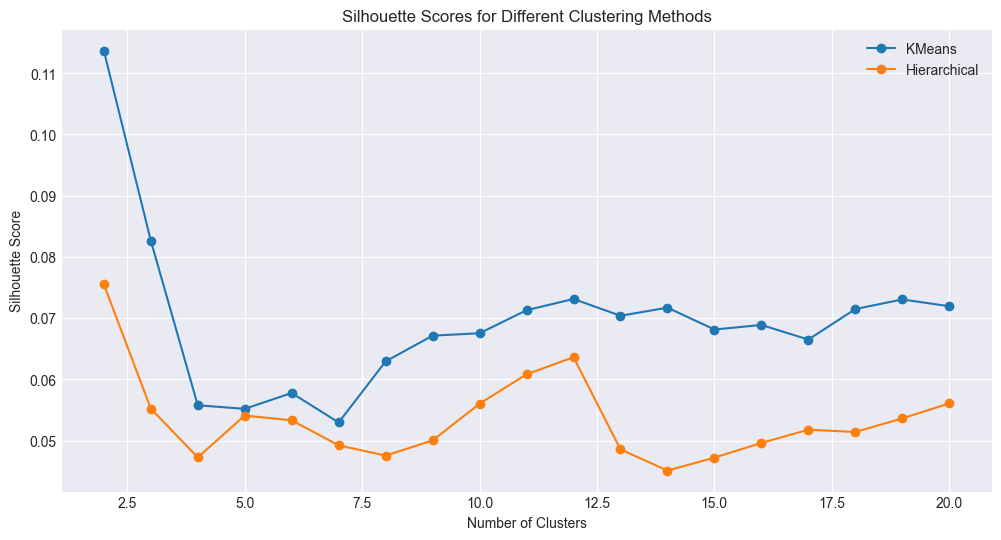

In [105]:

# Remove DBSCAN 
print(results.keys())
new_methods = ['KMeans', 'Hierarchical']

# Now, let's plot the silhouette scores for each method
plt.figure(figsize=(12, 6))
plt.style.use("seaborn-v0_8-dark")
for method in new_methods:
    cluster_nums = [res[0] for res in results[method]]
    silhouette_scores = [res[1] for res in results[method]]
    plt.plot(cluster_nums, silhouette_scores, marker='o', label=method)
plt.title('Silhouette Scores for Different Clustering Methods')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid()


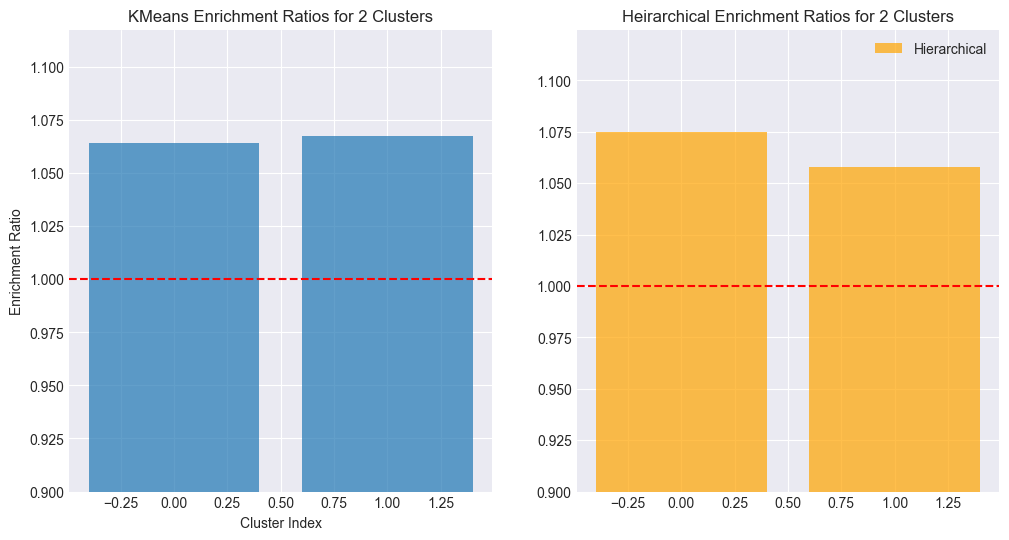

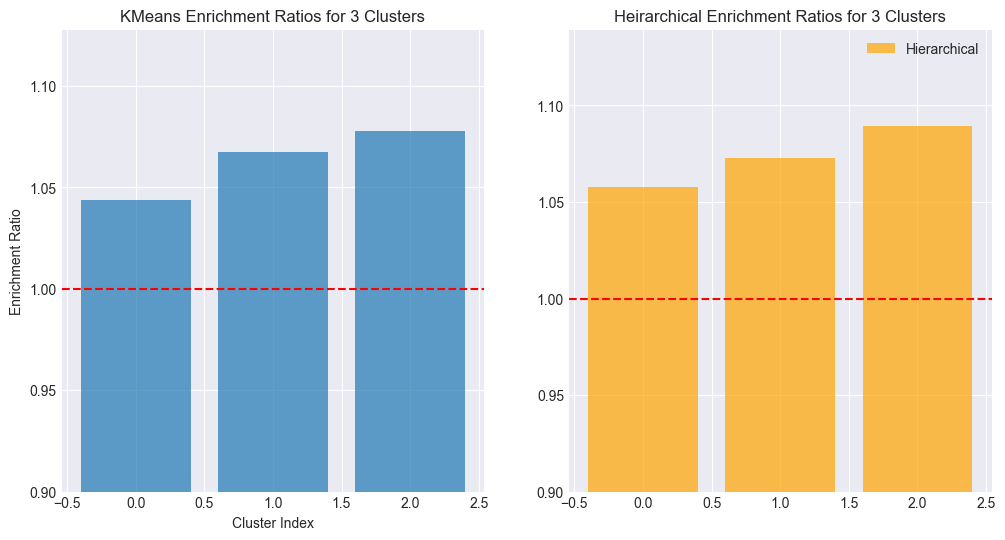

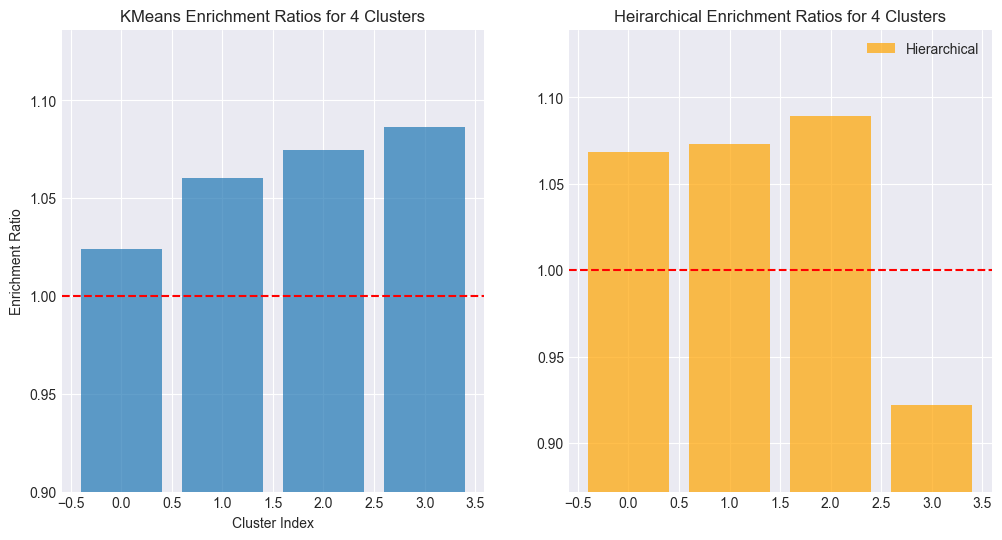

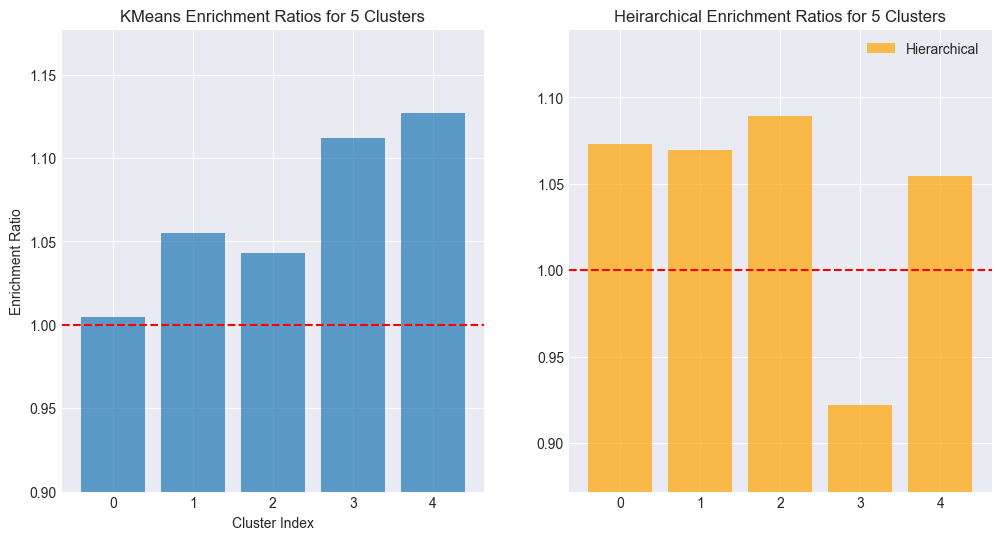

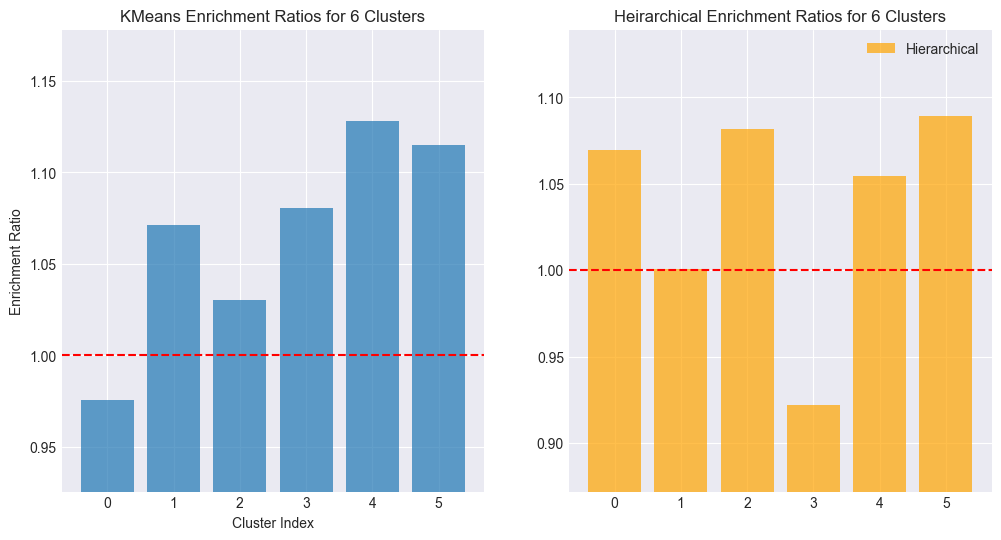

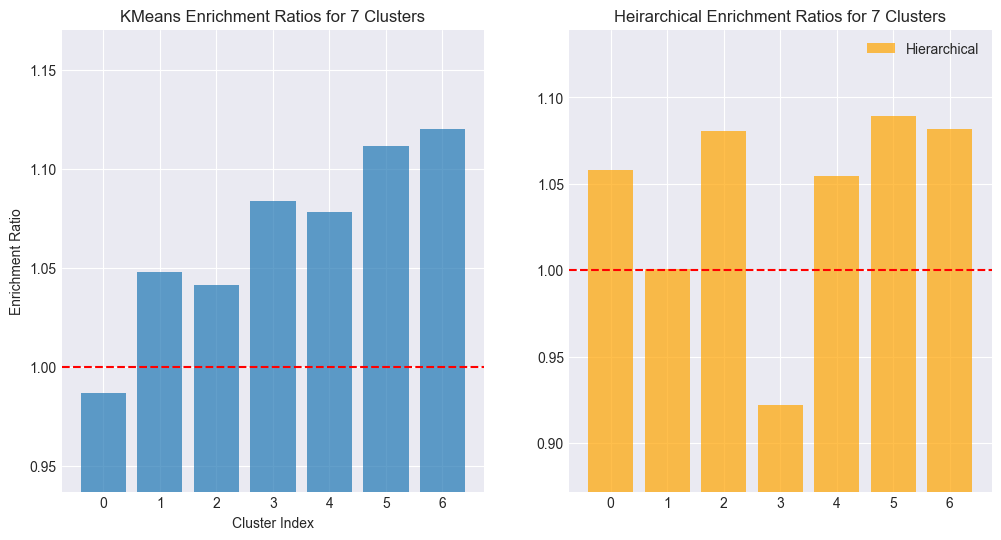

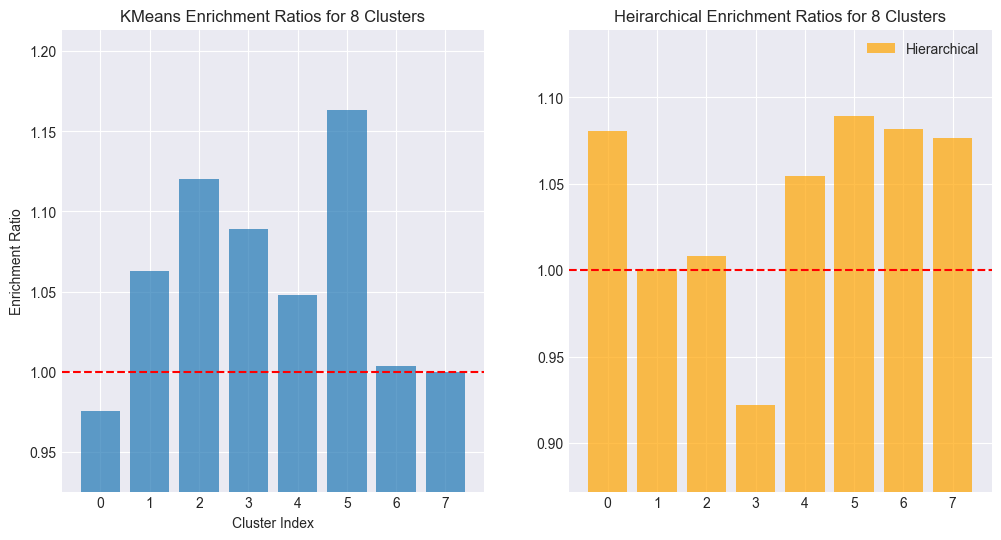

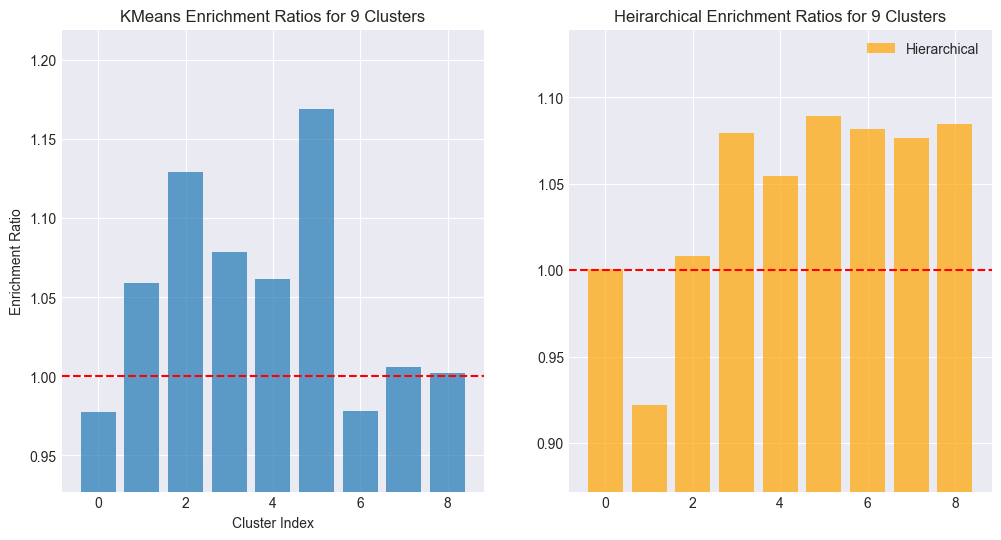

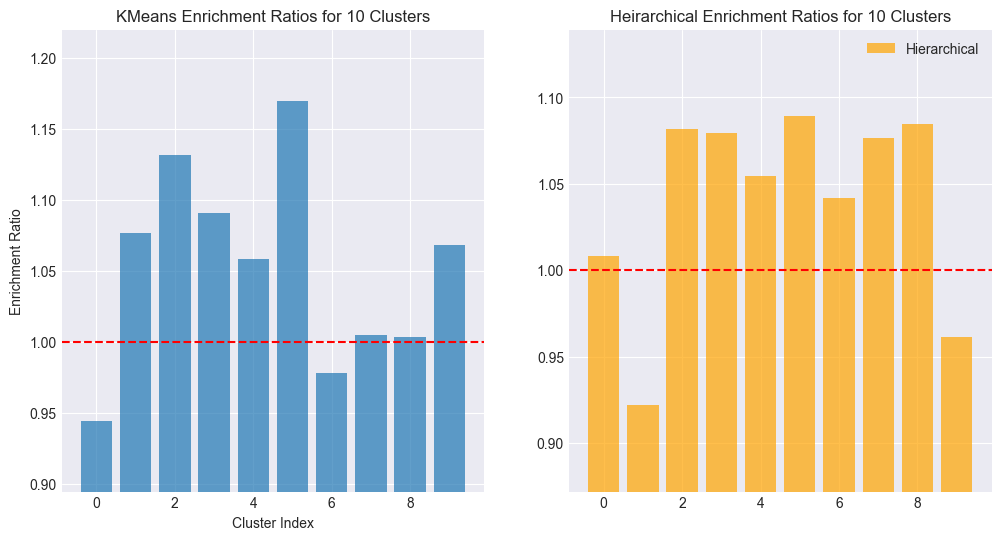

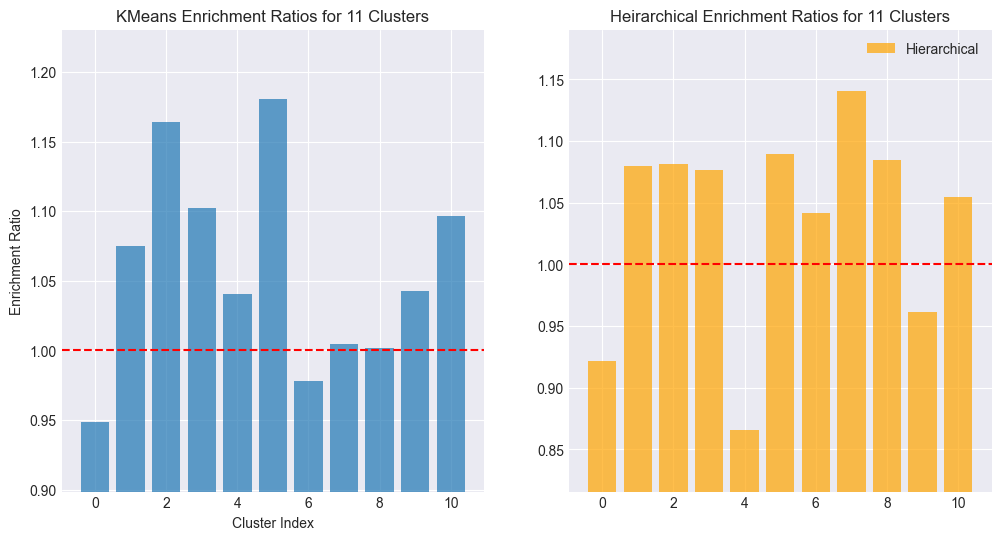

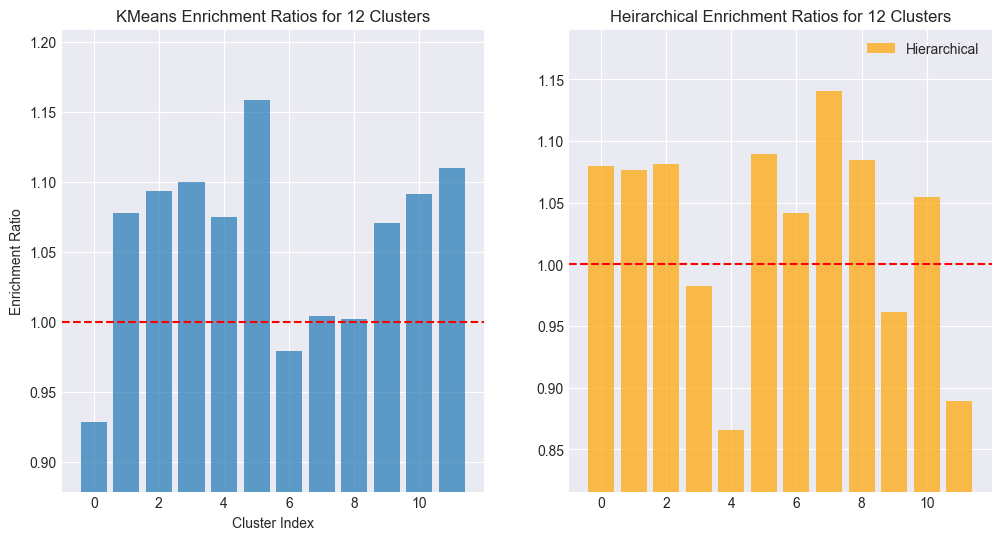

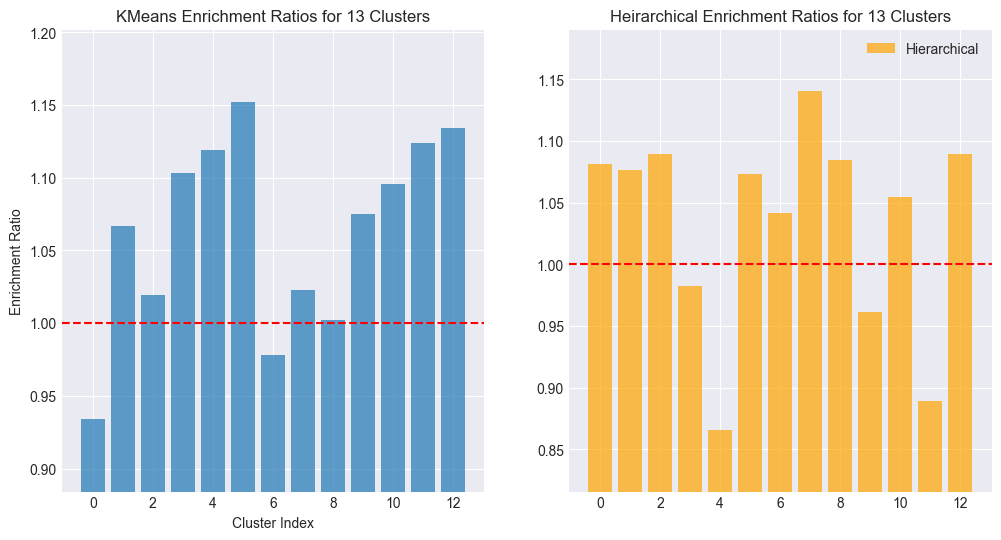

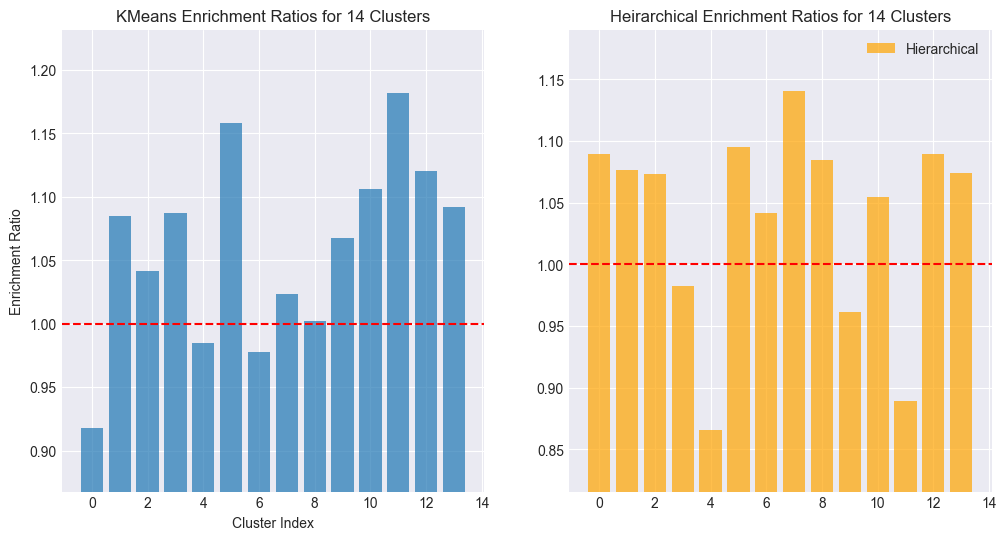

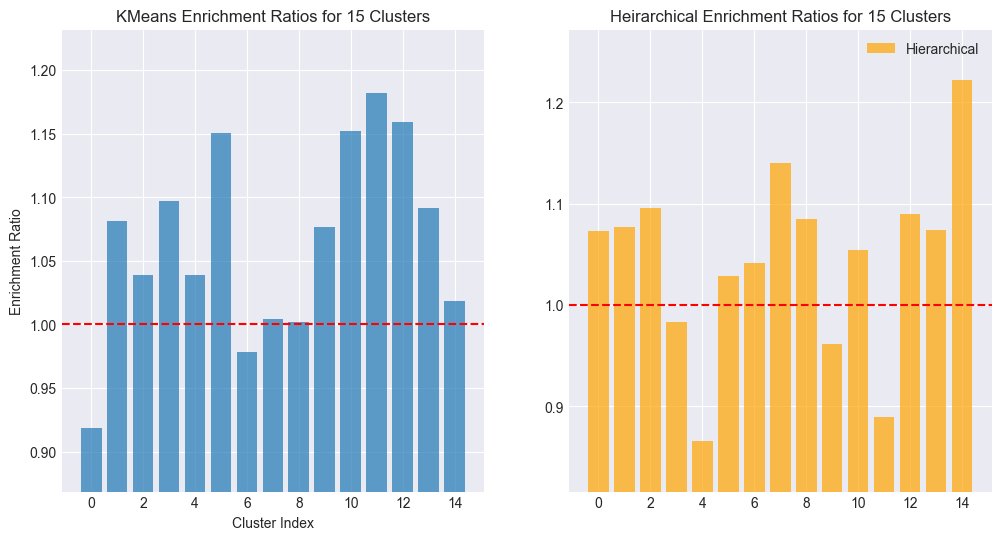

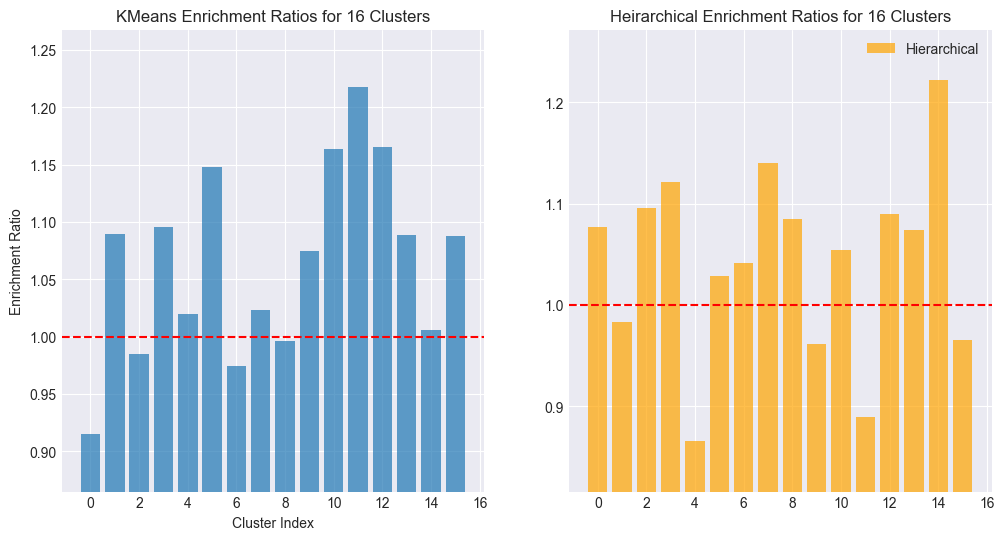

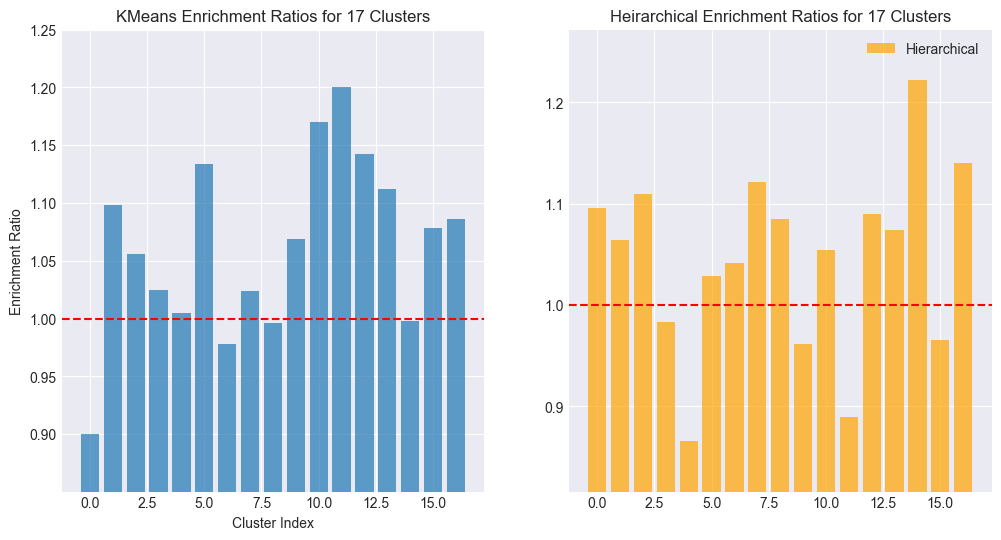

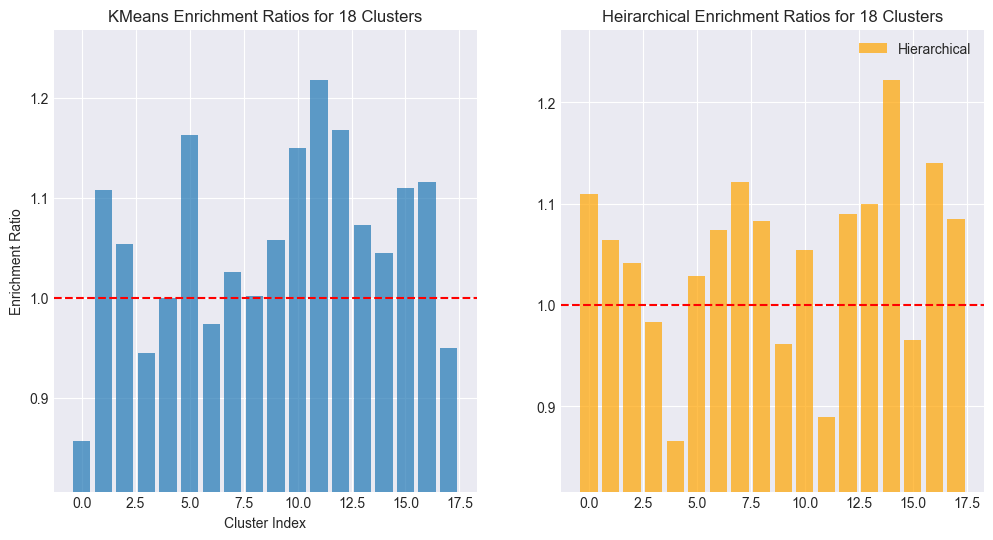

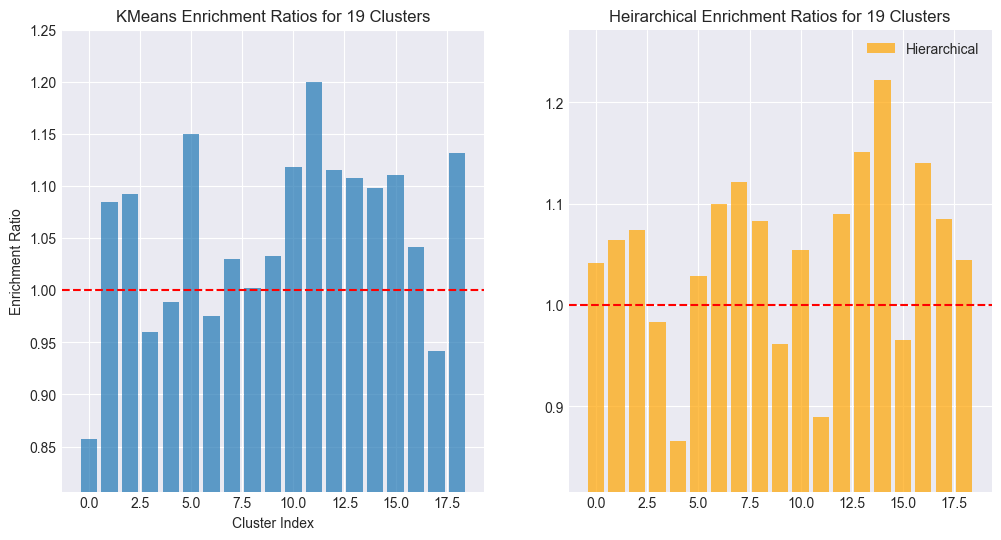

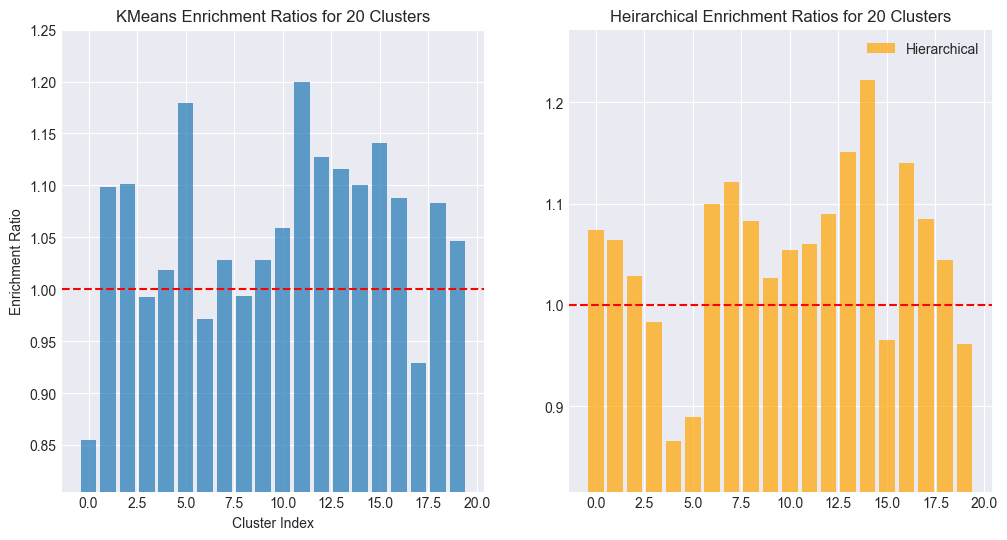

In [108]:
# Plot the enrichment ratios for each method and number of clusters
for n_clusters in range(2, 21):
    plt.figure(figsize=(12, 6))
    plt.style.use("seaborn-v0_8-dark")
    # set seaborn style
    
    k_means = results['KMeans'][n_clusters - 2][2]
    hierarchical = results['Hierarchical'][n_clusters - 2][2]
    
    # bar charts, subplots for each one
    ax = plt.subplot(1, 2, 1)
    plt.bar(range(len(k_means)), k_means, alpha=0.7, label='KMeans')
    plt.title(f'KMeans Enrichment Ratios for {n_clusters} Clusters')
    plt.xlabel('Cluster Index')
    plt.ylabel('Enrichment Ratio')
    y_min = min(k_means) - 0.05 if min(k_means) < 1 else 0.9
    y_max = max(k_means) + 0.05 if max(k_means) > 1 else 1.1
    plt.ylim(y_min, y_max)
    # draw a line at y=1
    plt.axhline(y=1, color='r', linestyle='--')
    plt.grid()
    
    
    ax = plt.subplot(1, 2, 2)
    plt.title(f'Heirarchical Enrichment Ratios for {n_clusters} Clusters')
    plt.bar(range(len(hierarchical)), hierarchical, alpha=0.7, label='Hierarchical', color='orange')
    y_min = min(hierarchical) - 0.05 if min(hierarchical) < 1 else 0.9
    y_max = max(hierarchical) + 0.05 if max(hierarchical) > 1 else 1.1
    plt.ylim(y_min, y_max)
    plt.axhline(y=1, color='r', linestyle='--')
    plt.legend()
    plt.grid()

   Cluster  StartCount  EndCount
0        0          63        52
1        1        1125       997
2        2         854       827
3        3         650       529
4        4         329       265
5        5         804       696
6        6        1095      1020
7        7         736       661
8        8        1200      1112
9        9         357       277


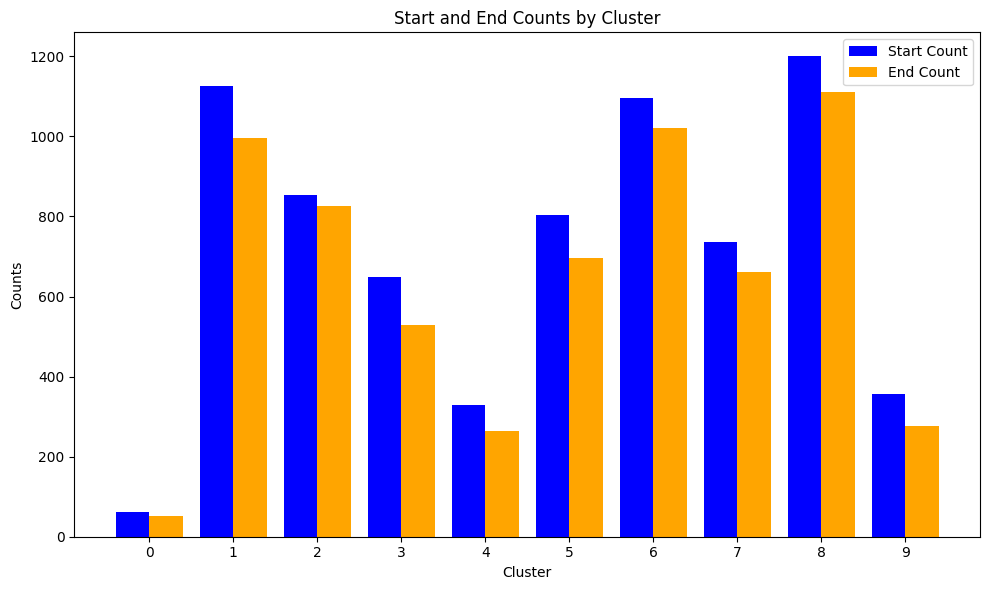

In [47]:
test_clusters = cluster_embeddings(embeddings, n_clusters=10)

# Remember the sequnces dataframe is df

start_nums = df['StartNumber']
end_nums = df['EndNumber']

# Create a new dataframe to hold the cluster information
cluster_df = pd.DataFrame({'Cluster': test_clusters, 'StartCount': start_nums[:10000], 'EndCount': end_nums[:10000]})
# sum the start and end counts for each cluster
cluster_summary = cluster_df.groupby('Cluster').sum().reset_index()

# Calculate enrichment ratios for each cluster
cluster_summary['EnrichmentRatio'] = cluster_summary.apply(
    lambda row: calculate_enrichment_ratio(row['StartCount'], row['EndCount'], total_sequences_before, total_sequences_after), axis=1)


print(cluster_summary)

# Plot the enrichment ratios
plt.figure(figsize=(10, 6))
plt.bar(cluster_summary['Cluster'], cluster_summary['EnrichmentRatio'], color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Enrichment Ratio')
plt.title('Enrichment Ratios by Cluster')
plt.xticks(cluster_summary['Cluster'])
plt.tight_layout()
plt.show()


"""print(cluster_summary)

# Now Plot them
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(cluster_summary['Cluster'] - 0.2, cluster_summary['StartCount'], width=0.4, label='Start Count', color='blue')
plt.bar(cluster_summary['Cluster'] + 0.2, cluster_summary['EndCount'], width=0.4, label='End Count', color='orange')
plt.xlabel('Cluster')
plt.ylabel('Counts')
plt.title('Start and End Counts by Cluster')
plt.xticks(cluster_summary['Cluster'])
plt.legend()
plt.tight_layout()
plt.show()"""

In [70]:
def get_count_embedding_df(embeddings: np.ndarray, df: pd.DataFrame, layer: int = -1) -> pd.DataFrame:
    """Create a dataframe with the embeddings and their corresponding before and after counts"""
    
    start_nums = df['StartNumber'].tolist()
    end_nums = df['EndNumber'].tolist()
    if layer != -1:
        embeddings = embeddings[:, layer, :]
    
    cluster_length = embeddings.shape[0]
    count_embedding_df = pd.DataFrame({'Embedding': list(embeddings), 
                                       'Start': start_nums[:cluster_length], 
                                       'End': end_nums[:cluster_length]})
    return count_embedding_df


def get_averages(df: pd.DataFrame, total_before: int, total_after: int) -> np.ndarray:
    """Get the average embedding array weighted by the before and after counts"""
    frequencies = get_frequencies(df, total_before, total_after)
    before_average = np.average(np.vstack(df['Embedding'].to_numpy()), axis=0, weights=frequencies[:, 0])
    after_average = np.average(np.vstack(df['Embedding'].to_numpy()), axis=0, weights=frequencies[:, 1])
    return np.vstack((before_average, after_average))


def get_frequencies(df: pd.DataFrame, total_before: int, total_after: int) -> np.ndarray:
    """Get the frequency counts for the before and after counts"""
    before_frequencies = df['Start'] / total_before
    after_frequencies = df['End'] / total_after
    return before_frequencies.to_numpy(), after_frequencies.to_numpy()

    

In [77]:
#rint(embeddings.shape)

count_embedding_test = get_count_embedding_df(embeddings, df, layer=12)
#enbedding_average_arrays = get_averages(count_embedding_test, total_sequences_before, total_sequences_after)

bef_freqs, aft_freqs = get_frequencies(count_embedding_test, total_sequences_before, total_sequences_after)
print(sum(bef_freqs), sum(aft_freqs))
embeddings_array = np.vstack(count_embedding_test['Embedding'].to_numpy())

print(embeddings_array.shape)
# normalize bef_freqs and aft_freqs to sum to 1
"""bef_freqs = bef_freqs / sum(bef_freqs)
aft_freqs = aft_freqs / sum(aft_freqs)
print(sum(bef_freqs), sum(aft_freqs))"""

(36668,)
(36668,)
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
[4.51611844e-04 4.10556222e-06 2.87389355e-04 ... 5.74778710e-05
 4.92667466e-05 3.07917166e-04]
1.3124004401162128 1.2157737283549903
(36668, 480)


'bef_freqs = bef_freqs / sum(bef_freqs)\naft_freqs = aft_freqs / sum(aft_freqs)\nprint(sum(bef_freqs), sum(aft_freqs))'

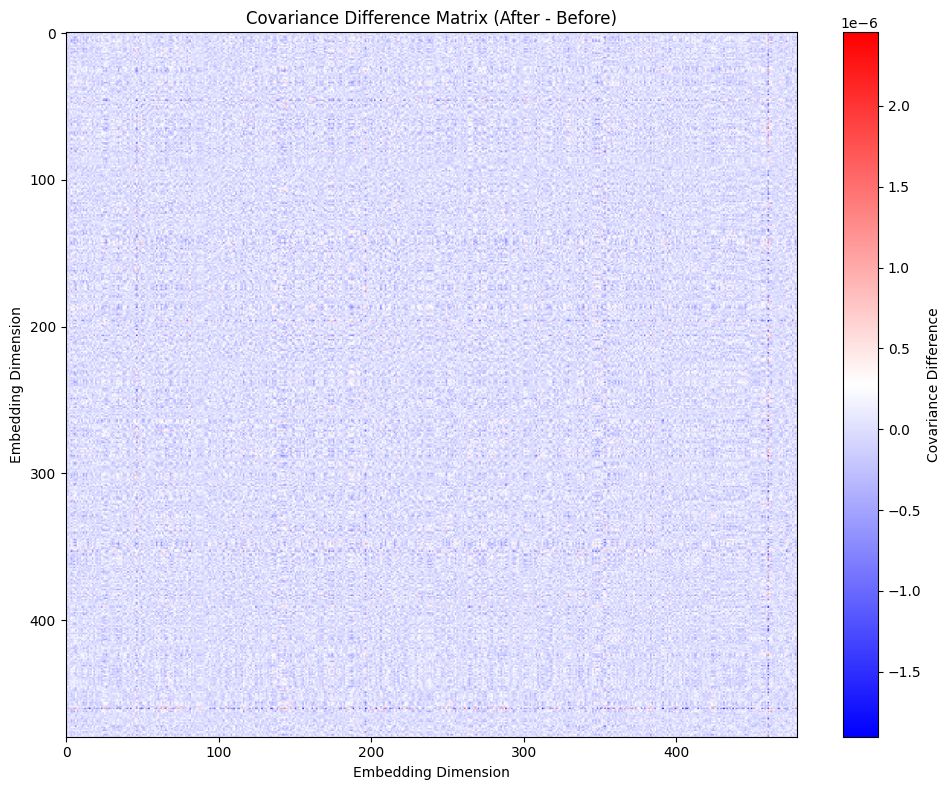

In [81]:
# generate a covariance array for before and after
cov_before = np.cov(embeddings_array.T, aweights=bef_freqs)
cov_after = np.cov(embeddings_array.T, aweights=aft_freqs)
cov_diff = cov_after - cov_before
# Plot the covariance difference matrix
plt.figure(figsize=(10, 8))
plt.imshow(cov_diff, cmap='bwr', aspect='auto')
plt.colorbar(label='Covariance Difference')
plt.title('Covariance Difference Matrix (After - Before)')
plt.xlabel('Embedding Dimension')
plt.ylabel('Embedding Dimension')
plt.tight_layout()
plt.show()


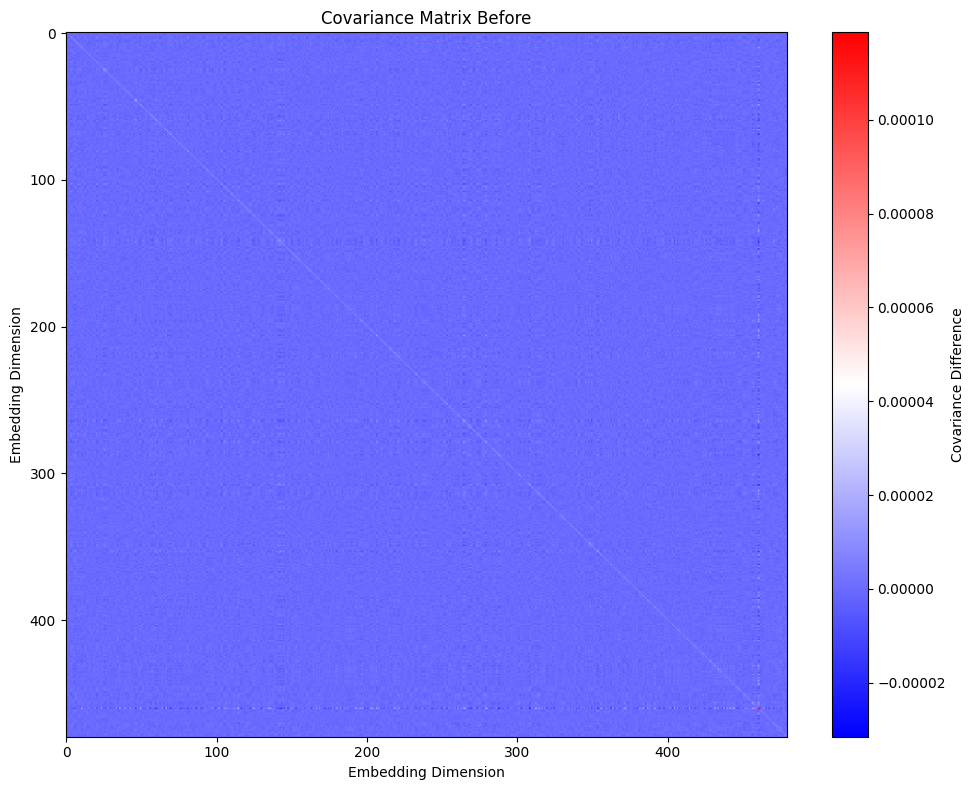

In [84]:
plt.figure(figsize=(10, 8))
plt.imshow(cov_before, cmap='bwr', aspect='auto')
plt.colorbar(label='Covariance Difference')
plt.title('Covariance Matrix Before')
plt.xlabel('Embedding Dimension')
plt.ylabel('Embedding Dimension')
plt.tight_layout()
plt.show()


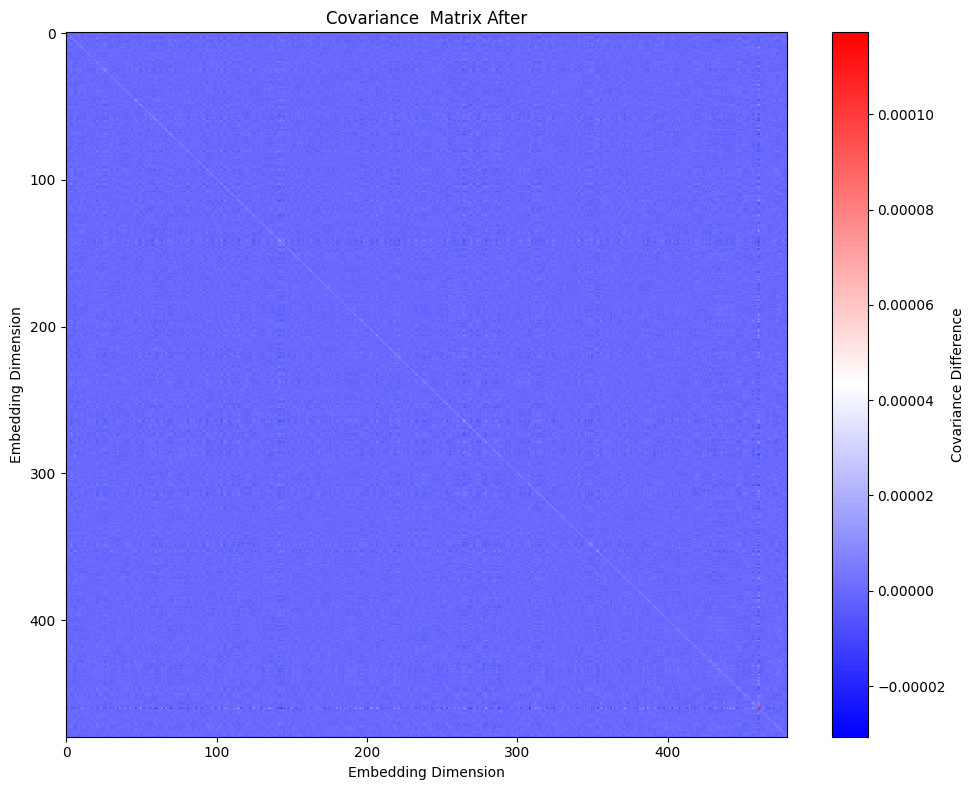

In [85]:
plt.figure(figsize=(10, 8))
plt.imshow(cov_after, cmap='bwr', aspect='auto')
plt.colorbar(label='Covariance Difference')
plt.title('Covariance  Matrix After')
plt.xlabel('Embedding Dimension')
plt.ylabel('Embedding Dimension')
plt.tight_layout()
plt.show()


In [86]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Heatmap(
                    z=cov_diff,
                    colorscale='Viridis'  # You can choose other color scales like 'Plasma', 'RdBu', etc.
                ))



fig.update_layout(
    title='Interactive 480x480 Covariance Matrix',
    xaxis_title="Variable Index",
    yaxis_title="Variable Index"
)

fig.show()

ModuleNotFoundError: No module named 'plotly'